<style>
    @import url('https://fonts.googleapis.com/css2?family=Oswald:wght@400;600&display=swap');
    h1.course-title {
        font-family: 'Oswald', sans-serif;
        font-size: 2.4em;
        color: #E7C173;
        letter-spacing: 0.05em;
        border-bottom: 2px solid #E7C173;
        padding-bottom: 0.3em;
        margin-bottom: 0.2em;
    }
    h2.course-subtitle { font-family: 'Oswald', sans-serif; color: #aaa; font-size: 1.2em; }
</style>

<h1 class='course-title'>MACHINE LEARNING IN INDUSTRY</h1>
<h2 class='course-subtitle'>Cardo AI · MSCA Digital Doctoral Network · Day 4</h2>

# Day 4, Block 2 — Experiment Tracking with MLflow

## Table of Contents
1. [Scope and Success Criteria](#1-scope)
2. [What is MLflow? The Four Components](#2-mlflow)
3. [Launch the Tracking Server](#3-server)
4. [Imports and Setup](#4-setup)
5. [A First Tracked Run](#5-first-run)
6. [Hyperparameter Sweep — Cross-Validated](#6-sweep)
7. [Model Diagnostics — Calibration and Fairness](#7-diagnostics)
8. [The Model Registry — Aliases](#8-registry)
9. [Loading a Registered Model](#9-loading)
10. [Acceptance Checks](#10-checks)

---
## 1. Scope and Success Criteria <a id='1-scope'></a>

By the end of this notebook you should be able to:

- **Start** a local MLflow tracking server and navigate its UI
- **Log** hyperparameters, metrics, and a serialised model to an MLflow run
- **Compare** multiple runs in the MLflow UI side by side
- **Register** a model version and transition it through stages (Staging → Production)
- **Load** a registered model and reproduce its predictions

> **Time budget:** this notebook covers Block 2 (≈30 minutes). We move fast — the goal is to *see the workflow*, not memorise every API call.

---
## 2. What is MLflow? The Four Components <a id='2-mlflow'></a>

MLflow is an open-source platform for the complete ML lifecycle. It has four main components:

| Component | What it does | Used today |
|---|---|---|
| **Tracking** | Logs runs: params, metrics, tags, artifacts | Blocks 2 & 3 |
| **Projects** | Reproducible run packaging (`MLproject` file) | `day4/MLproject` |
| **Models** | Model serialisation with "flavors" (sklearn, lgbm, …) | `predict.py` |
| **Registry** | Model versioning and stage lifecycle | Block 2 |

**Local vs. production:** Today, MLflow runs entirely on your laptop. In production, you point `MLFLOW_TRACKING_URI` at a shared remote server backed by a cloud storage bucket. The code is *identical* — only the URI changes.

---
## 3. Launch the Tracking Server <a id='3-server'></a>

Open a **separate terminal**, `cd` to the repo root, and run:

```bash
make -f day4/Makefile mlflow-server
# or directly:
mlflow server --host 127.0.0.1 --port 5000 --backend-store-uri sqlite:///day4/mlflow.db --default-artifact-root ./day4/mlartifacts
```

Then open **http://127.0.0.1:5000** in your browser.

> **Why SQLite?** The default file-based store (`mlruns/`) works for a single machine. SQLite gives us a proper database backend that persists cleanly for the Model Registry. In production this would be PostgreSQL or MySQL.

---
## 4. Imports and Setup <a id='4-setup'></a>

In [1]:
# Guard: check the MLflow server is reachable before we proceed
import urllib.request, urllib.error
MLFLOW_URI = "http://127.0.0.1:5000"
try:
    urllib.request.urlopen(f"{MLFLOW_URI}/health", timeout=2)
    print(f"✓ MLflow server is running at {MLFLOW_URI}")
except urllib.error.URLError:
    print(f"⚠  MLflow server not reachable at {MLFLOW_URI}")
    print("   Run in a separate terminal:")
    print("   make -f day4/Makefile mlflow-server")

✓ MLflow server is running at http://127.0.0.1:5000


In [2]:
import sys
from pathlib import Path

import mlflow
import mlflow.sklearn
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

# Make day4/ importable
repo_root = Path.cwd().parent.parent
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from day4.src.train import (
    DATA_PATH, SEED, TARGET_BIN_COL,
    build_pipeline, get_feature_columns, load_data, split_data,
)

# ── MLflow configuration ──────────────────────────────────────────────────────
EXPERIMENT_NAME = "adult-income-lgbm"
MODEL_NAME = "adult-income-classifier"

mlflow.set_tracking_uri(MLFLOW_URI)
mlflow.set_experiment(EXPERIMENT_NAME)
print(f"Tracking URI : {mlflow.get_tracking_uri()}")
print(f"Experiment   : {EXPERIMENT_NAME}")

Tracking URI : http://127.0.0.1:5000
Experiment   : adult-income-lgbm


In [3]:
# ── Load and split data (same conventions as Days 1-2) ────────────────────────
data_path = repo_root / DATA_PATH
df = load_data(data_path)
train_df, val_df, test_df = split_data(df)

numeric_cols, categorical_cols = get_feature_columns(train_df)
feature_cols = numeric_cols + categorical_cols

X_train = train_df[feature_cols]
y_train = train_df[TARGET_BIN_COL]
X_val   = val_df[feature_cols]
y_val   = val_df[TARGET_BIN_COL]

print(f"Train: {len(X_train)} rows | Val: {len(X_val)} rows")
print(f"Features: {len(feature_cols)} ({len(numeric_cols)} numeric, {len(categorical_cols)} categorical)")

Train: 5909 rows | Val: 1488 rows
Features: 19 (12 numeric, 7 categorical)


---
## 5. A First Tracked Run <a id='5-first-run'></a>

The core MLflow API is three calls inside a context manager:

```python
with mlflow.start_run():
    mlflow.log_params(...)   # hyperparameters — things you chose
    mlflow.log_metrics(...)  # numbers you measured — AUC, F1, …
    mlflow.sklearn.log_model(pipe, artifact_path="model")  # the serialised model
```

That's it. We are **not** changing the training code — we are just *wrapping* it.

In [4]:
params = {"n_estimators": 300, "learning_rate": 0.1, "max_depth": 5}

with mlflow.start_run(run_name="baseline") as run:
    # 1️⃣ Log what you chose
    mlflow.log_params(params)
    mlflow.log_param("seed", SEED)

    # 2️⃣ Train (same pipeline as Day 2)
    pipe = build_pipeline(numeric_cols, categorical_cols, **params)
    pipe.fit(X_train, y_train)

    # 3️⃣ Measure
    val_proba = pipe.predict_proba(X_val)[:, 1]
    val_pred  = pipe.predict(X_val)
    metrics = {
        "val_auc":      round(roc_auc_score(y_val, val_proba), 4),
        "val_f1":       round(f1_score(y_val, val_pred), 4),
        "val_accuracy": round(accuracy_score(y_val, val_pred), 4),
    }
    mlflow.log_metrics(metrics)

    # 4️⃣ Persist the model
    mlflow.sklearn.log_model(pipe, artifact_path="model")

    baseline_run_id = run.info.run_id

print(f"Run ID  : {baseline_run_id}")
print(f"Metrics : {metrics}")
print(f"\nOpen {MLFLOW_URI} → experiment '{EXPERIMENT_NAME}' → run 'baseline'")

/Users/gennaro.dibrino/projects/ml_industry_course/day4/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/gennaro.dibrino/projects/ml_industry_course/day4/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
2026/03/18 10:14:51 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/18 10:14:51 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/03/18

🏃 View run baseline at: http://127.0.0.1:5000/#/experiments/1/runs/23718af3355e4de1b6d5abc16693a4d0
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1
Run ID  : 23718af3355e4de1b6d5abc16693a4d0
Metrics : {'val_auc': 0.9084, 'val_f1': 0.7273, 'val_accuracy': 0.8387}

Open http://127.0.0.1:5000 → experiment 'adult-income-lgbm' → run 'baseline'


**Navigate the MLflow UI now:**
1. Click on the experiment `adult-income-lgbm`
2. Click the run named `baseline`
3. Explore the **Parameters**, **Metrics**, and **Artifacts** tabs
4. Download the logged model and inspect its directory structure

---
## 6. Hyperparameter Sweep — Cross-Validated <a id='6-sweep'></a>

Without logging, comparing runs means keeping a spreadsheet (or relying on memory). MLflow makes this systematic.

**Why cross-validation matters here:** with ~1,500 validation rows, the standard error of AUC is roughly 0.01–0.02. If the AUC difference between two configs is smaller than that, a single split cannot distinguish them — you are comparing noise. GroupKFold with `person_id` as the group key gives us variance estimates while maintaining entity-aware splits.

In [5]:
from sklearn.model_selection import GroupKFold
from sklearn.metrics import brier_score_loss

N_FOLDS = 3
train_all = pd.concat([train_df, val_df], ignore_index=True)
X_all = train_all[feature_cols]
y_all = train_all[TARGET_BIN_COL]
groups = train_all["person_id"]

sweep_configs = [
    {"n_estimators": 100, "learning_rate": 0.10, "max_depth": 3},
    {"n_estimators": 300, "learning_rate": 0.10, "max_depth": 5},  # Day 2 best
    {"n_estimators": 300, "learning_rate": 0.05, "max_depth": 5},
    {"n_estimators": 500, "learning_rate": 0.05, "max_depth": 7},
]

sweep_results = []
gkf = GroupKFold(n_splits=N_FOLDS)

for cfg in sweep_configs:
    fold_aucs = []
    run_label = f"n{cfg['n_estimators']}_lr{cfg['learning_rate']}_d{cfg['max_depth']}"

    with mlflow.start_run(run_name=run_label) as run:
        mlflow.log_params(cfg)
        mlflow.log_param("n_folds", N_FOLDS)

        for fold_idx, (train_idx, val_idx) in enumerate(gkf.split(X_all, y_all, groups)):
            pipe = build_pipeline(numeric_cols, categorical_cols, **cfg)
            pipe.fit(X_all.iloc[train_idx], y_all.iloc[train_idx])
            vl_proba = pipe.predict_proba(X_all.iloc[val_idx])[:, 1]
            fold_aucs.append(roc_auc_score(y_all.iloc[val_idx], vl_proba))

        auc_mean = float(np.mean(fold_aucs))
        auc_std = float(np.std(fold_aucs))
        mlflow.log_metrics({"val_auc_mean": auc_mean, "val_auc_std": auc_std})

        # Retrain on all data, log final model
        pipe_final = build_pipeline(numeric_cols, categorical_cols, **cfg)
        pipe_final.fit(X_all, y_all)
        mlflow.sklearn.log_model(pipe_final, artifact_path="model")

        sweep_results.append({
            **cfg, "val_auc_mean": auc_mean, "val_auc_std": auc_std,
            "run_id": run.info.run_id,
        })
        print(f"  {run_label:40s}  AUC={auc_mean:.4f} ± {auc_std:.4f}")

sweep_df = pd.DataFrame(sweep_results).sort_values("val_auc_mean", ascending=False)
display(sweep_df)

best_run_id = sweep_df.iloc[0]["run_id"]
print(f"\nBest config: AUC={sweep_df.iloc[0]['val_auc_mean']:.4f} ± {sweep_df.iloc[0]['val_auc_std']:.4f}")
print(f"Run ID: {best_run_id}")

/Users/gennaro.dibrino/projects/ml_industry_course/day4/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/gennaro.dibrino/projects/ml_industry_course/day4/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/gennaro.dibrino/projects/ml_industry_course/day4/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
2026/03/18 10:14:55 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/18 10:14:55 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Pytho

  n100_lr0.1_d3                             AUC=0.9122 ± 0.0077
🏃 View run n100_lr0.1_d3 at: http://127.0.0.1:5000/#/experiments/1/runs/49864a23b05f4763ad034d8ee1dafb62
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


/Users/gennaro.dibrino/projects/ml_industry_course/day4/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/gennaro.dibrino/projects/ml_industry_course/day4/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/gennaro.dibrino/projects/ml_industry_course/day4/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
2026/03/18 10:15:01 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/18 10:15:01 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Pytho

  n300_lr0.1_d5                             AUC=0.9070 ± 0.0096
🏃 View run n300_lr0.1_d5 at: http://127.0.0.1:5000/#/experiments/1/runs/a511c31ea8d14a3e8f03a70ba52641de
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


/Users/gennaro.dibrino/projects/ml_industry_course/day4/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/gennaro.dibrino/projects/ml_industry_course/day4/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/gennaro.dibrino/projects/ml_industry_course/day4/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
2026/03/18 10:15:08 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/18 10:15:08 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Pytho

  n300_lr0.05_d5                            AUC=0.9112 ± 0.0087
🏃 View run n300_lr0.05_d5 at: http://127.0.0.1:5000/#/experiments/1/runs/c475d79752104af0b2d852215c6a53ce
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


/Users/gennaro.dibrino/projects/ml_industry_course/day4/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/gennaro.dibrino/projects/ml_industry_course/day4/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/gennaro.dibrino/projects/ml_industry_course/day4/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
2026/03/18 10:15:19 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/18 10:15:19 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Pytho

  n500_lr0.05_d7                            AUC=0.9060 ± 0.0093
🏃 View run n500_lr0.05_d7 at: http://127.0.0.1:5000/#/experiments/1/runs/beaba62e93d24233abcbd1ef2cf42690
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


,n_estimators,learning_rate,max_depth,val_auc_mean,val_auc_std,run_id
0,100,0.10,3,0.912155,0.007659,49864a23b05f4763ad034d8ee1dafb62
2,300,0.05,5,0.911213,0.008731,c475d79752104af0b2d852215c6a53ce
1,300,0.10,5,0.907011,0.009556,a511c31ea8d14a3e8f03a70ba52641de
3,500,0.05,7,0.906019,0.009332,beaba62e93d24233abcbd1ef2cf42690



Best config: AUC=0.9122 ± 0.0077
Run ID: 49864a23b05f4763ad034d8ee1dafb62


**In the MLflow UI:**
- Select all four runs and click **Compare**
- Note how the `val_auc_std` column reveals which configs have overlapping confidence intervals
- If two configs have AUC means within 1 std of each other, the difference is likely noise

> **Multiple comparisons warning:** With 4 configs, the probability that the *best-looking* one is a false positive (due to random variance) is non-trivial. With 20 configs at alpha=0.05, P(at least one false positive) = 1 - (0.95)^20 = 64%. Always report mean ± std, and treat small differences with skepticism.

---
## 7. Model Diagnostics — Calibration and Fairness <a id='7-diagnostics'></a>

Before promoting a model, you need to know more than its aggregate AUC. Two critical diagnostics:

1. **Calibration:** Does a predicted probability of 0.3 actually correspond to a 30% positive rate? This matters for any downstream score-based monitoring (PSI on scores) and for business decisions that rely on probability thresholds.

2. **Subgroup performance:** Does the model perform equitably across demographic groups? A model with AUC=0.91 overall might have AUC=0.93 for one group and AUC=0.82 for another — which is a fairness concern and, in regulated industries, a compliance risk.

> **Reference:** Barocas, Hardt & Narayanan (2019) — [*Fairness and Machine Learning*](https://fairmlbook.org/). Reporting per-subgroup metrics is the minimum standard for responsible deployment.

/Users/gennaro.dibrino/projects/ml_industry_course/day4/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


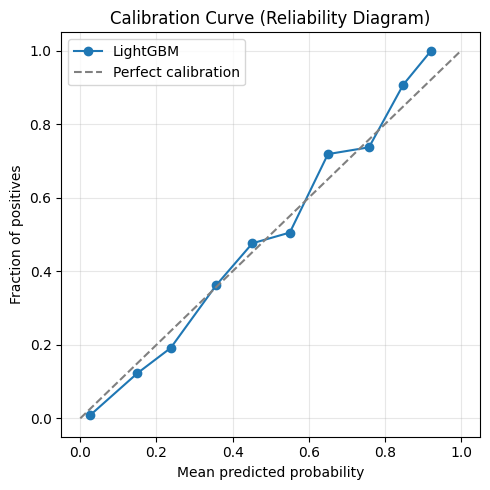

Brier score: 0.1022  (lower is better; 0.25 = random baseline)


In [6]:
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt

# Load the best model from the sweep
best_pipe = mlflow.sklearn.load_model(f"runs:/{best_run_id}/model")

# Get predictions on the held-out val set
val_proba = best_pipe.predict_proba(X_val)[:, 1]

# ── Calibration curve ─────────────────────────────────────────────────────────
prob_true, prob_pred = calibration_curve(y_val, val_proba, n_bins=10)

fig, ax = plt.subplots(1, 1, figsize=(5, 5))
ax.plot(prob_pred, prob_true, marker="o", label="LightGBM")
ax.plot([0, 1], [0, 1], "--", color="gray", label="Perfect calibration")
ax.set_xlabel("Mean predicted probability")
ax.set_ylabel("Fraction of positives")
ax.set_title("Calibration Curve (Reliability Diagram)")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Brier score: 0 = perfect, 0.25 = random for balanced classes
brier = brier_score_loss(y_val, val_proba)
print(f"Brier score: {brier:.4f}  (lower is better; 0.25 = random baseline)")

In [7]:
# ── Subgroup performance (fairness diagnostic) ───────────────────────────────
print("Per-subgroup AUC breakdown:")
print(f"  {'Overall':20s}  AUC={roc_auc_score(y_val, val_proba):.4f}  (n={len(y_val)})")
print()

for group_col in ["marital_status", "workclass"]:
    if group_col not in val_df.columns:
        continue
    print(f"  By {group_col}:")
    for group_val in sorted(val_df[group_col].dropna().unique()):
        mask = val_df[group_col] == group_val
        n_group = mask.sum()
        if n_group < 30:  # too few for a reliable estimate
            print(f"    {group_val:30s}  n={n_group} (too few)")
            continue
        group_auc = roc_auc_score(y_val[mask], val_proba[mask])
        print(f"    {group_val:30s}  AUC={group_auc:.4f}  (n={n_group})")
    print()

Per-subgroup AUC breakdown:
  Overall               AUC=0.9250  (n=1488)

  By marital_status:
    Adm-clerical                    n=2 (too few)
    Craft-repair                    n=3 (too few)
    Divorced                        AUC=0.9189  (n=290)
    Exec-managerial                 n=2 (too few)
    Married-civ-spouse              AUC=0.9258  (n=270)
    Never-married                   AUC=0.8933  (n=323)
    Other-service                   n=3 (too few)
    Separated                       AUC=0.9351  (n=302)
    Widowed                         AUC=0.9475  (n=293)

  By workclass:
    Divorced                        n=5 (too few)
    Federal-gov                     AUC=0.9136  (n=302)
    Local-gov                       AUC=0.9420  (n=284)
    Married-civ-spouse              n=3 (too few)
    Never-married                   n=3 (too few)
    Private                         AUC=0.9229  (n=312)
    Self-emp-not-inc                AUC=0.9244  (n=282)
    State-gov                     

**What to look for:**

- **Calibration curve close to diagonal** = the model's probabilities are trustworthy. LightGBM is usually well-calibrated out of the box, but always verify — downstream score-based monitoring (PSI on scores) relies on this.
- **Subgroup AUC gaps** = if performance differs significantly across groups, investigate. Is the training data underrepresenting a subgroup? Is the feature set less informative for certain groups? In regulated domains, these gaps must be documented and justified.

> In production, both diagnostics should be logged as MLflow artifacts on every training run — not just checked once.

---
## 8. The Model Registry — Aliases <a id='8-registry'></a>

The **Tracking** server stores experiment records. The **Registry** is a separate layer that manages the *deployment lifecycle* of a model version.

MLflow uses **aliases** to label which version is currently serving a given role:

```
Version 1  →  (no alias)
Version 2  →  @champion      ← the one we deploy
Version 3  →  @challenger    ← under validation
```

In a financial services context, moving a model to `@champion` typically requires a sign-off from a model risk team. MLflow captures that paper trail: who set the alias, when, and from which run.

> **Note:** Older MLflow tutorials use "stages" (Staging/Production/Archived). This API is deprecated since MLflow 2.9. Aliases are the replacement — they are more flexible (you can define any alias name) and don't carry the baggage of a fixed lifecycle.

In [8]:
best_run_id = sweep_df.iloc[0]["run_id"]
model_uri   = f"runs:/{best_run_id}/model"

# Register the best run's model
result = mlflow.register_model(model_uri=model_uri, name=MODEL_NAME)
version = result.version
print(f"Registered version: {version}")

Registered model 'adult-income-classifier' already exists. Creating a new version of this model...
2026/03/18 10:15:22 WARNING mlflow.tracking._model_registry.fluent: Run with id 49864a23b05f4763ad034d8ee1dafb62 has no artifacts at artifact path 'model', registering model based on models:/m-3e785119f35345219b20d319dcc6647d instead
2026/03/18 10:15:22 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: adult-income-classifier, version 2


Registered version: 2


Created version '2' of model 'adult-income-classifier'.


In [9]:
client = mlflow.tracking.MlflowClient()

# Set the "champion" alias on the registered version
client.set_registered_model_alias(MODEL_NAME, "champion", version)
print(f"Version {version} → alias 'champion'")
print(f"\nOpen {MLFLOW_URI}/#/models/{MODEL_NAME} to inspect the Registry.")

Version 2 → alias 'champion'

Open http://127.0.0.1:5000/#/models/adult-income-classifier to inspect the Registry.


---
## 9. Loading a Registered Model <a id='9-loading'></a>

Two load patterns:
- `models:/<name>@<alias>` — always loads the version tagged as champion (good for serving)
- `runs:/<run_id>/model` — loads a specific run's artifact (good for reproducibility)

In [10]:
# Pattern 1: load from Registry by alias
champion_model = mlflow.sklearn.load_model(f"models:/{MODEL_NAME}@champion")

# Pattern 2: load from a specific run
run_model = mlflow.sklearn.load_model(f"runs:/{best_run_id}/model")

# Both should produce identical predictions
sample = X_val.head(5)
pred_champion = champion_model.predict_proba(sample)[:, 1]
pred_run = run_model.predict_proba(sample)[:, 1]

assert np.allclose(pred_champion, pred_run), "Models are NOT identical!"
print("✓ Both models produce identical predictions.")
print(pd.DataFrame({"P(>50K) @champion": pred_champion, "P(>50K) from Run": pred_run}))

✓ Both models produce identical predictions.
   P(>50K) @champion  P(>50K) from Run
0           0.086997          0.086997
1           0.527355          0.527355
2           0.536632          0.536632
3           0.590839          0.590839
4           0.795585          0.795585


/Users/gennaro.dibrino/projects/ml_industry_course/day4/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/gennaro.dibrino/projects/ml_industry_course/day4/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


---
## 10. Acceptance Checks <a id='10-checks'></a>

In [11]:
# ── Run all acceptance checks ─────────────────────────────────────────────────
exp = mlflow.get_experiment_by_name(EXPERIMENT_NAME)
assert exp is not None, f"Experiment '{EXPERIMENT_NAME}' not found"

runs = mlflow.search_runs(experiment_ids=[exp.experiment_id])
assert len(runs) >= 4, f"Expected ≥4 runs, found {len(runs)}"

# Baseline logs val_auc; sweep logs val_auc_mean — each run should have at least one
has_auc = runs["metrics.val_auc"].notna() | runs["metrics.val_auc_mean"].notna()
assert has_auc.all(), "Some runs are missing both val_auc and val_auc_mean"

# Sanity: all AUC values above chance
best_auc = runs[["metrics.val_auc", "metrics.val_auc_mean"]].max(axis=1)
assert (best_auc > 0.5).all(), "AUC below chance level — something is wrong"

champion_version = client.get_model_version_by_alias(MODEL_NAME, "champion")
assert champion_version is not None, "No model version with alias 'champion'"

print("✓ Experiment exists")
print(f"✓ {len(runs)} runs logged")
print(f"✓ All runs have AUC metric  (best: {best_auc.max():.4f})")
print(f"✓ Model '{MODEL_NAME}' has a champion version (v{champion_version.version})")
print("\nAll acceptance checks passed.")

✓ Experiment exists
✓ 15 runs logged
✓ All runs have AUC metric  (best: 0.9122)
✓ Model 'adult-income-classifier' has a champion version (v2)

All acceptance checks passed.
